# Exjobb Cgroup Analysis

In [412]:
%pip install numpy matplotlib pandas

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statistics

Note: you may need to restart the kernel to use updated packages.


In [413]:
def get_cgroup_recording(expid, runid, relpath):
    df = pd.read_csv(f'./traces/{expid}/{runid}/cg/{relpath}')
    return df

def get_trace_dataset(expid, runid):
    df = pd.read_csv(f'./traces/{expid}/{runid}/{runid}-trace.csv')
    return df

def get_experiment_info(expid):
    info = {}
    with open(f'./traces/{expid}/info.txt', 'r') as f:
        for i, line in enumerate(f):
            if i == 7:
                info['Dataplane'] = line.split(':')[1].strip()
            elif i == 8:
                info['Protocol'] = line.split(':')[1].strip()
            elif i == 9:
                info['Policy Direction'] = line.split(':')[1].strip()
            elif i == 10:
                info['Istio Installed'] = line.split(':')[1].strip()
            elif i == 11:
                info['Istio Policy'] = line.split(':')[1].strip()
    
    return info



In [414]:
def udp_get_timestamp_of_first_and_last_packet(expid: str, runid: str):
    df = get_trace_dataset(expid, runid)
    first = df['timestamp1'].iloc[0]
    last = df['timestamp1'].iloc[-1]
    return (first, last)


def get_cpu_usec_from_run(expid: str, runid: str, filter=None, file_path="system/cpu.stat.csv"):
    """Calculates the used CPU time from a run"""
    df = get_cgroup_recording(expid, runid, file_path)

    if filter == "UDP":
        timestamp_packets = udp_get_timestamp_of_first_and_last_packet(expid, runid)
        # Convert seconds to nanoseconds for comparison with cpu.stat.csv timestamps
        ts_first_ns = timestamp_packets[0] * 1e9
        ts_second_ns = timestamp_packets[1] * 1e9
        # Filter rows to only include those between the first and second packet
        df = df[(df['snapshot'] >= ts_first_ns) & (df['snapshot'] <= ts_second_ns)]

    delta = df['usage_usec'].iloc[-1] - df['usage_usec'].iloc[0]
    print(f"EXPID: {expid}, RUNID: {runid}, DELTA={delta}")
    return delta

def get_mean_cpu_usec_from_exp(expid: str, filter=None, file_path="system/cpu.stat.csv"):
    usecs = []
    for i in range(1, 4):
        usecs.append(get_cpu_usec_from_run(expid, str(i), filter, file_path))
    mean = statistics.mean(usecs)
    print(f"Mean: {mean}")
    
    return mean

def get_mean_usec_per_request(expid: str, filter=None, file_path="system/cpu.stat.csv"):
    return get_mean_cpu_usec_from_exp(expid, filter, file_path) / 1000
    


#print(get_cpu_usec_from_run("40634", "1"))
get_mean_usec_per_request("40634")

EXPID: 40634, RUNID: 1, DELTA=142647000
EXPID: 40634, RUNID: 2, DELTA=140770000
EXPID: 40634, RUNID: 3, DELTA=145825000
Mean: 143080666


np.float64(143080.666)

In [415]:
def get_mem_usage_from_run(expid: str, runid: str, file_path="system/meminfo.csv"):
    """Calculates mean used memory for a run from meminfo snapshots (MB)."""
    df = get_cgroup_recording(expid, runid, file_path)

    mem_used_kb = df['MemTotal'] - df['MemAvailable']
    mean_used_mb = mem_used_kb.mean() / 1024
    print(f"EXPID: {expid}, RUNID: {runid}, MEAN_MEM_USED_MB={mean_used_mb}")
    return mean_used_mb


def get_mean_mem_usage_from_exp(expid: str, filter=None, file_path="system/meminfo.csv"):
    mem_usage = []
    for i in range(1, 4):
        mem_usage.append(get_mem_usage_from_run(expid, str(i), file_path))
    mean = statistics.mean(mem_usage)
    print(f"Mean: {mean}")
    
    return mean

In [416]:
def get_mean_pod_memory_usage_expid(expid, cgroup_dir_name):
    mem_usage = []
    for i in range(1, 4):
        df = get_cgroup_recording(expid, i, f"{cgroup_dir_name}/memory.current.csv")
        mean_usage = df["value"].mean() / (1024 * 1024)
        mem_usage.append(mean_usage)
    total_mean = statistics.mean(mem_usage)
    print(f"Mean mem_usage for EXPID: {expid}, {cgroup_dir_name} = {total_mean} MB")
    return total_mean

In [417]:
def plot_bar_cpu_per_req(experimentstocompare, axs, index, filter=None):
    for exp in experimentstocompare:
        val = get_mean_usec_per_request(exp['id'], filter)
        key = get_experiment_info(exp['id'])['Policy Direction']
        axs[index].set_title(get_experiment_info(exp['id'])['Dataplane'])
        axs[index].bar(key, val)

In [418]:
def plot_bar_cpu_per_req_istio(experimentstocompare, axs, index):
    for exp in experimentstocompare:
        sys_val = get_mean_usec_per_request(exp['id'])
        #istio_proxy_val = get_mean_usec_per_request(exp['id'], file_path="istio-proxy/cpu.stat.csv")
        label = f"Istio: {get_experiment_info(exp['id'])['Istio Installed'].capitalize()} - Policy: {get_experiment_info(exp['id'])['Istio Policy']}"
        axs[index].set_title(get_experiment_info(exp['id'])['Dataplane'])
        axs[index].barh(label, sys_val)
        axs[index].tick_params(axis='x', rotation=45, )

In [419]:
def plot_bar_mem_usage_istio(experimentstocompare, axs, index):
    for exp in experimentstocompare:
        sys_val = get_mean_mem_usage_from_exp(exp['id'])
        #istio_proxy_val = get_mean_usec_per_request(exp['id'], file_path="istio-proxy/cpu.stat.csv")
        label = f"Istio: {get_experiment_info(exp['id'])['Istio Installed'].capitalize()} - Policy: {get_experiment_info(exp['id'])['Istio Policy']}"
        axs[index].set_title(get_experiment_info(exp['id'])['Dataplane'])
        axs[index].barh(label, sys_val)
        axs[index].tick_params(axis='x', rotation=45, )

EXPID: 40634, RUNID: 1, DELTA=140425000
EXPID: 40634, RUNID: 2, DELTA=138719000
EXPID: 40634, RUNID: 3, DELTA=143265000
Mean: 140803000
EXPID: 40635, RUNID: 1, DELTA=137398000
EXPID: 40635, RUNID: 2, DELTA=141739000
EXPID: 40635, RUNID: 3, DELTA=138190000
Mean: 139109000
EXPID: 40636, RUNID: 1, DELTA=134327000
EXPID: 40636, RUNID: 2, DELTA=139546000
EXPID: 40636, RUNID: 3, DELTA=137513000
Mean: 137128666
EXPID: 40637, RUNID: 1, DELTA=145962000
EXPID: 40637, RUNID: 2, DELTA=140001000
EXPID: 40637, RUNID: 3, DELTA=141619000
Mean: 142527333
EXPID: 40725, RUNID: 1, DELTA=138639000
EXPID: 40725, RUNID: 2, DELTA=137565000
EXPID: 40725, RUNID: 3, DELTA=138440000
Mean: 138214666
EXPID: 40726, RUNID: 1, DELTA=133056000
EXPID: 40726, RUNID: 2, DELTA=138465000
EXPID: 40726, RUNID: 3, DELTA=138282000
Mean: 136601000
EXPID: 40727, RUNID: 1, DELTA=141543000
EXPID: 40727, RUNID: 2, DELTA=137197000
EXPID: 40727, RUNID: 3, DELTA=136925000
Mean: 138555000
EXPID: 40728, RUNID: 1, DELTA=136001000
EXPID: 4

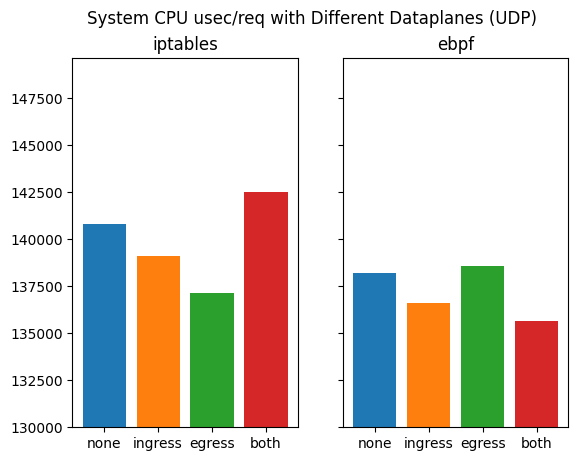

In [420]:
fig, axs = plt.subplots(1,2,sharey=True)
fig.suptitle('System CPU usec/req with Different Dataplanes (UDP)')

# UDP Iptables
experimentstocompare = [{'id': '40634'}, {'id': '40635'}, {'id': '40636'}, {'id': '40637'}]
plot_bar_cpu_per_req(experimentstocompare, axs, index=0, filter="UDP")

# UDP eBPF
experimentstocompare = [{'id': '40725'}, {'id': '40726'}, {'id': '40727'}, {'id': '40728'}]
plot_bar_cpu_per_req(experimentstocompare, axs, index=1, filter="UDP")

axs[0].set(ylim=130000)
plt.savefig('plots/cpu_usec_udp.pdf', format='pdf')

# HTTP Istio

EXPID: 40638, RUNID: 1, DELTA=143666000
EXPID: 40638, RUNID: 2, DELTA=153719000
EXPID: 40638, RUNID: 3, DELTA=140434000
Mean: 145939666
EXPID: 40659, RUNID: 1, DELTA=201358000
EXPID: 40659, RUNID: 2, DELTA=205889000
EXPID: 40659, RUNID: 3, DELTA=205859000
Mean: 204368666
EXPID: 40669, RUNID: 1, DELTA=206582000
EXPID: 40669, RUNID: 2, DELTA=195817000
EXPID: 40669, RUNID: 3, DELTA=205730000
Mean: 202709666
EXPID: 40687, RUNID: 1, DELTA=221459000
EXPID: 40687, RUNID: 2, DELTA=226329000
EXPID: 40687, RUNID: 3, DELTA=218070000
Mean: 221952666
EXPID: 40686, RUNID: 1, DELTA=225183000
EXPID: 40686, RUNID: 2, DELTA=228174000
EXPID: 40686, RUNID: 3, DELTA=229920000
Mean: 227759000
EXPID: 40729, RUNID: 1, DELTA=140242000
EXPID: 40729, RUNID: 2, DELTA=138020000
EXPID: 40729, RUNID: 3, DELTA=140021000
Mean: 139427666
EXPID: 40734, RUNID: 1, DELTA=200257000
EXPID: 40734, RUNID: 2, DELTA=201393000
EXPID: 40734, RUNID: 3, DELTA=195659000
Mean: 199103000
EXPID: 40733, RUNID: 1, DELTA=203066000
EXPID: 4

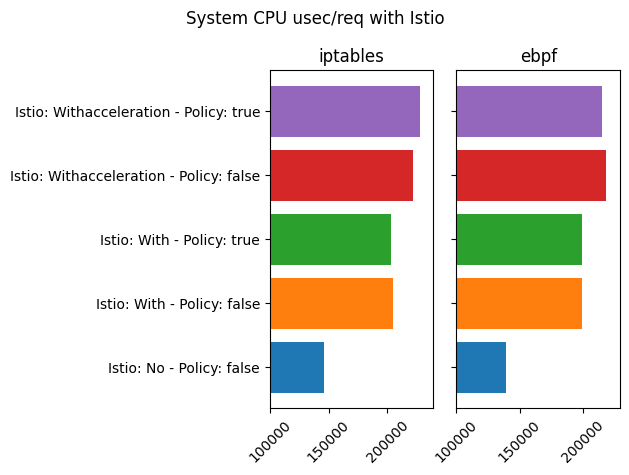

In [421]:
fig, axs = plt.subplots(1, 2,sharey=True)
fig.suptitle('System CPU usec/req with Istio')


# Iptables
experimentstocompare = [{'id': '40638', 'run': '1'}, {'id': '40659', 'run': '1'}, {'id': '40669', 'run': '1'}, {'id': '40687', 'run': '1'}, {'id': '40686', 'run': '1'}]
plot_bar_cpu_per_req_istio(experimentstocompare, axs, index=0)


# eBPF
experimentstocompare = [{'id': '40729', 'run': '1'}, {'id': '40734', 'run': '1'}, {'id': '40733', 'run': '1'}, {'id': '40742', 'run': '1'}, {'id': '40741', 'run': '1'}]
plot_bar_cpu_per_req_istio(experimentstocompare, axs, index=1)

#fig.legend(axs[0].get_legend_handles_labels()[0], axs[0].get_legend_handles_labels()[1], loc='upper center', bbox_to_anchor=(0.5, 0), ncol=2)

plt.savefig('plots/cpu_usec_comparison_istio.pdf', format='pdf', bbox_inches='tight')
plt.tight_layout()
axs[0].set(xlim=100000)
axs[1].set(xlim=100000)
plt.show()

# Memory Istio

Plot how much memory Istio components use on average.

Mean mem_usage for EXPID: 40748, istio-proxy = 29.431584041787733 MB
Mean mem_usage for EXPID: 40748, discovery = 129.46210837420193 MB
Mean mem_usage for EXPID: 40748, merbridge = 181.7516301643797 MB


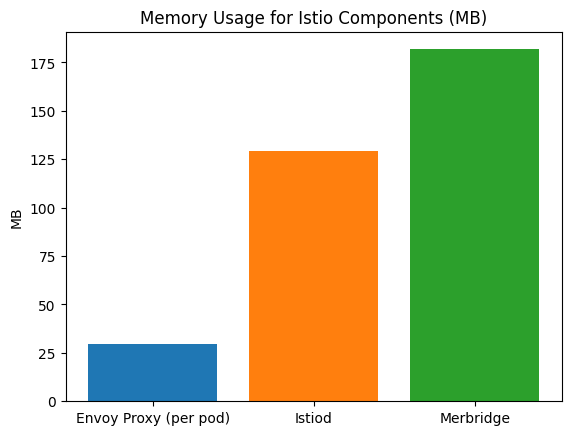

In [424]:
plt.title("Memory Usage for Istio Components (MB)")
plt.bar("Envoy Proxy (per pod)", get_mean_pod_memory_usage_expid("40748", "istio-proxy"))
plt.bar("Istiod", get_mean_pod_memory_usage_expid("40748", "discovery"))
plt.bar("Merbridge", get_mean_pod_memory_usage_expid("40748", "merbridge"))
plt.ylabel("MB")

plt.savefig('plots/istio_mem_usage.pdf', format='pdf', bbox_inches='tight')